![QuantConnect Logo](https://cdn.quantconnect.com/web/i/icon.png)
<hr>

## Quiver Government Contracts Research

This notebook studies whether government contract dollar volume helps explain future returns

In [1]:
qb = QuantBook()
# Daily bars will have an end_time that matches the following midnight.
qb.settings.daily_precise_end_time = False
# Anchor the research clock to the start of 2026.
qb.set_start_date(2026, 1, 1)

### Build a Government Contract Universe

Select assets with frequent, sizable US government contracts, then inspect the returned universe history.

In [2]:
def select_assets(data: List[QuiverGovernmentContractUniverse]) -> List[Symbol]:
    # Group by ticker and keep names with 3+ contracts totalling over $50K.
    contracts_by_symbol: dict[Symbol, list[QuiverGovernmentContractUniverse]] = {}
    for d in data:
        contracts_by_symbol.setdefault(d.symbol, []).append(d)
    return [s for s, ds in contracts_by_symbol.items()
            if len(ds) >= 3 and sum(x.amount or 0 for x in ds) > 50_000]

# Add the Quiver Government Contract universe.
universe = qb.add_universe(QuiverGovernmentContractUniverse, select_assets)
# Request universe history of the last 90 days.
universe_history = qb.universe_history(universe, qb.time - timedelta(90), qb.time - timedelta(1), flatten=True).rename_axis(['time', 'symbol']).drop(columns=['time'])
# Print the returned shape and columns.
print(f"Shape: {universe_history.shape}")
print(f"Columns: {list(universe_history.columns)}")
universe_history.head()

Shape: (580, 4)
Columns: ['agency', 'amount', 'description', 'value']


agency  amount  \
time       symbol                                                       
2025-10-04 DNOW VR22RBI5MBFP  General Services Administration  138.66   
           DNOW VR22RBI5MBFP  General Services Administration  346.65   
           DNOW VR22RBI5MBFP  General Services Administration  452.85   
           DNOW VR22RBI5MBFP  General Services Administration  905.70   
           DNOW VR22RBI5MBFP  General Services Administration  374.20   

                                                                    description  \
time       symbol                                                                 
2025-10-04 DNOW VR22RBI5MBFP                                            78C10M0   
           DNOW VR22RBI5MBFP                                            78C10M0   
           DNOW VR22RBI5MBFP  CARTRIDGE; TONER I.A.W. HEWLETT PACKARD P/N: C...   
           DNOW VR22RBI5MBFP  CARTRIDGE; TONER I.A.W. HEWLETT PACKARD P/N: C...   
           DNOW VR22RBI5MBFP  CARTRIDGE; TONER I.A.W. HEWLETT PACKARD P/N: C...   

                               value  
time       symbol                     
2025-10-04 DNOW VR22RBI5MBFP  138.66  
           DNOW VR22RBI5MBFP  346.65  
           DNOW VR22RBI5MBFP  452.85  
           DNOW VR22RBI5MBFP  905.70  
           DNOW VR22RBI5MBFP  374.20

### Universe Diagnostics

Inspects the raw contract amount distribution and visualizes how the daily universe size evolves chronologically.

Universe days: 19
Mean basket size per day: 2.6

count        580.000
mean       20138.930
std       105049.143
min            0.000
25%          259.200
50%          618.250
75%         1741.500
max      1776510.800
Name: amount, dtype: object


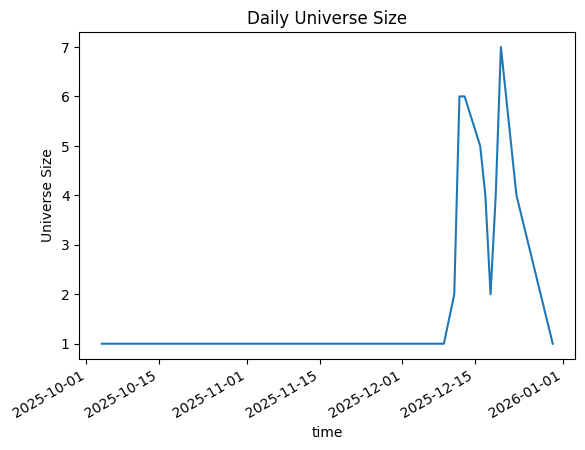

In [3]:
# Count selected assets by day.
universe_size = universe_history.reset_index().groupby(['time', 'symbol']).size().groupby('time').size()
print(f"Universe days: {len(universe_size)}")
# Store the selected symbol list.
unique_assets = list(universe_history.index.levels[1].unique())
print(f"Mean basket size per day: {universe_size.mean():.1f}")
print('')
print(universe_history.amount.describe().map('{:0.3f}'.format))
universe_size.plot(title='Daily Universe Size', ylabel='Universe Size');

### Daily Universe Prices

Fetch daily price history for every symbol that appears in the universe.

In [4]:
# Extract unique assets
symbols = list(universe_history.index.get_level_values(1).unique())
# Fetch daily historical price metrics using the earliest timestamp available in the index.
history = qb.history(symbols, universe_history.index[0][0] - timedelta(1), qb.time, Resolution.DAILY)
history

close     high     low   open     volume
symbol            time                                                 
DNOW VR22RBI5MBFP 2025-10-04  15.770  15.8300  15.330  15.39  1016905.0
                  2025-10-07  15.910  16.2600  15.822  15.86  1095631.0
                  2025-10-08  15.510  15.9200  15.285  15.81  1093552.0
                  2025-10-09  15.660  15.7999  15.560  15.65   778108.0
                  2025-10-10  14.690  15.6800  14.690  15.56   952082.0
...                              ...      ...     ...    ...        ...
MDLN YYDBHHPS742T 2025-12-25  44.280  45.0100  43.550  43.95  4363660.0
                  2025-12-27  44.085  45.4500  43.610  44.50  8118252.0
                  2025-12-30  42.090  43.8000  41.735  43.57  5517778.0
                  2025-12-31  41.820  43.2500  41.620  42.05  4102917.0
                  2026-01-01  42.000  43.0700  41.210  41.94  5587994.0

[816 rows x 5 columns]

### Align Contract Volume And Returns

Build a joined table of contract dollar volume and future returns.

In [5]:
dataset = (
    universe_history.reset_index().groupby(['time', 'symbol']).agg(dollarvolume=('amount', 'sum'))
    .join(history.open.unstack('symbol').sort_index().pct_change(2, fill_method=None).shift(-2).stack().rename('futurereturn').rename_axis(['time','symbol']), how='inner')
)
dataset.head()

,,dollarvolume,futurereturn
time,symbol,,
2025-10-04,DNOW VR22RBI5MBFP,222382.01,0.027290
2025-10-08,SYK R735QTJ8XC9X,450063.66,0.024027
2025-10-10,DNOW VR22RBI5MBFP,294421.70,-0.087404
2025-11-15,SENEA R735QTJ8XC9X,798649.20,0.031759
2025-11-18,SENEA R735QTJ8XC9X,798649.20,0.026921


### Analyze Relationships Between Factor and Future Returns

Drop the 1% outliers on each side of the factor and fit a line of best fit.

Factor: dollarvolume
Observations: 46
Mean future return: 0.84%
Alpha: 1.09%
Beta: -0.00%
R-squared: 1.94%


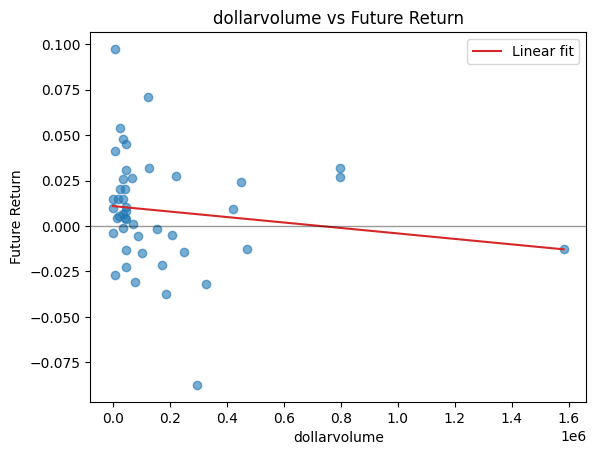

In [6]:
factor = 'dollarvolume'
# Assign the factor values.
x = dataset[factor]
y = dataset['futurereturn']
# Drop the 1% outliers on each side of the factor.
lower, upper = x.quantile([0.01, 0.99])
mask = x.between(lower, upper)
x, y = x[mask], y[mask]
# Fit a simple linear model.
slope, intercept = np.polyfit(x, y, 1)
r_squared = x.corr(y) ** 2
# Print the linear model statistics.
print(f"Factor: {factor}")
print(f"Observations: {len(x)}")
print(f"Mean future return: {y.mean():.2%}")
print(f"Alpha: {intercept:.2%}")
print(f"Beta: {slope:.2%}")
print(f"R-squared: {r_squared:.2%}")
# Plot the factor values against future returns.
plt.scatter(x, y, alpha=0.6)
plt.plot(x.sort_values(), intercept + slope * x.sort_values(), color='tab:red', label='Linear fit')
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'{factor} vs Future Return')
plt.xlabel(factor)
plt.ylabel('Future Return')
plt.legend()
plt.show()

Create a box plot of dollar-volume quantile buckets compared to future returns.

Factor: dollarvolume


,bucket,mean_factor,min_future_return,max_future_return,mean_future_return,std_future_return,observations
0,"(48.149, 25000.0]",11731.199,-2.68%,9.74%,2.10%,3.31%,11
1,"(25000.0, 44524.0]",39489.625,-0.11%,4.80%,1.53%,1.61%,8
2,"(44524.0, 76500.0]",53859.619,-3.06%,4.51%,0.62%,2.53%,9
3,"(76500.0, 222382.01]",154137.782,-3.74%,7.10%,0.50%,3.30%,9
4,"(222382.01, 1581867.01]",599279.908,-8.74%,3.18%,-0.74%,3.72%,9


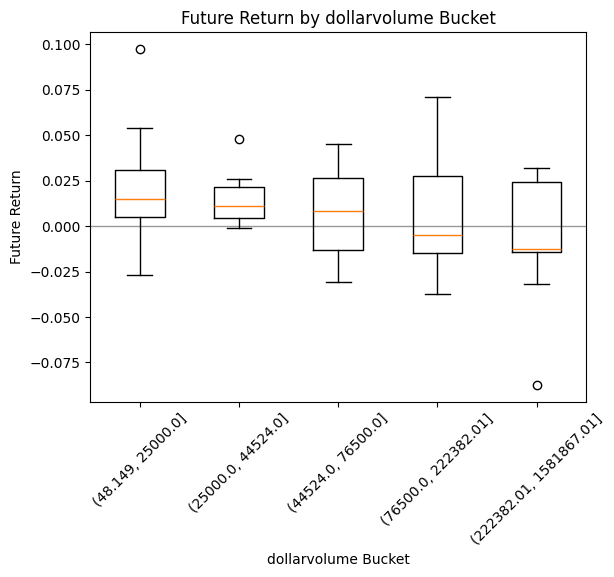

In [7]:
# Split factor values into quantile buckets.
buckets = pd.qcut(x, q=5, duplicates='drop')
# Summarize each bucket with distribution statistics.
summary = dataset.assign(bucket=buckets).groupby('bucket', observed=True).agg(
    mean_factor=(factor, 'mean'),
    min_future_return=('futurereturn', 'min'),
    max_future_return=('futurereturn', 'max'),
    mean_future_return=('futurereturn', 'mean'),
    std_future_return=('futurereturn', 'std'),
    observations=('futurereturn', 'size')
).reset_index()
summary['bucket'] = summary['bucket'].astype(str)
# Display the bucket summary.
print(f"Factor: {factor}")
display(summary.style.format({
    'mean_factor': '{:.3f}',
    'min_future_return': '{:.2%}',
    'max_future_return': '{:.2%}',
    'mean_future_return': '{:.2%}',
    'std_future_return': '{:.2%}'
}))
# Plot the return distribution for each bucket.
groups = [y[buckets == b].values for b in buckets.cat.categories]
plt.boxplot(groups, labels=[str(b) for b in buckets.cat.categories])
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.title(f'Future Return by {factor} Bucket')
plt.xlabel(f'{factor} Bucket')
plt.ylabel('Future Return')
plt.xticks(rotation=45)
plt.show()